──────────────────────────────────────────────────────────────────────────────────────────────────────
  Функция            | Метод                  | старт x*       | x*                     | f(x*)      | iter   | точек
──────────────────────────────────────────────────────────────────────────────────────────────────────
  Квадр. (b=1)       | Градиентный спуск      | (3.00 , 3.00 ) | (0.00000  , 0.00000  ) | 0.000000   | 10     | 11
  Квадр. (b=1)       | Наискорейший спуск     | (3.00 , 3.00 ) | (0.00000  , 0.00000  ) | 0.000000   | 2      | 3
  Квадр. (b=1)       | Сопряж. градиенты      | (3.00 , 3.00 ) | (0.00000  , 0.00000  ) | 0.000000   | 2      | 3
──────────────────────────────────────────────────────────────────────────────────────────────────────
  Квадр. (b=10)      | Градиентный спуск      | (3.00 , 3.00 ) | (0.00000  , 0.00000  ) | 0.000000   | 72     | 73
  Квадр. (b=10)      | Наискорейший спуск     | (3.00 , 3.00 ) | (0.00000  , -0.00000 ) | 0.000000   | 13     | 14


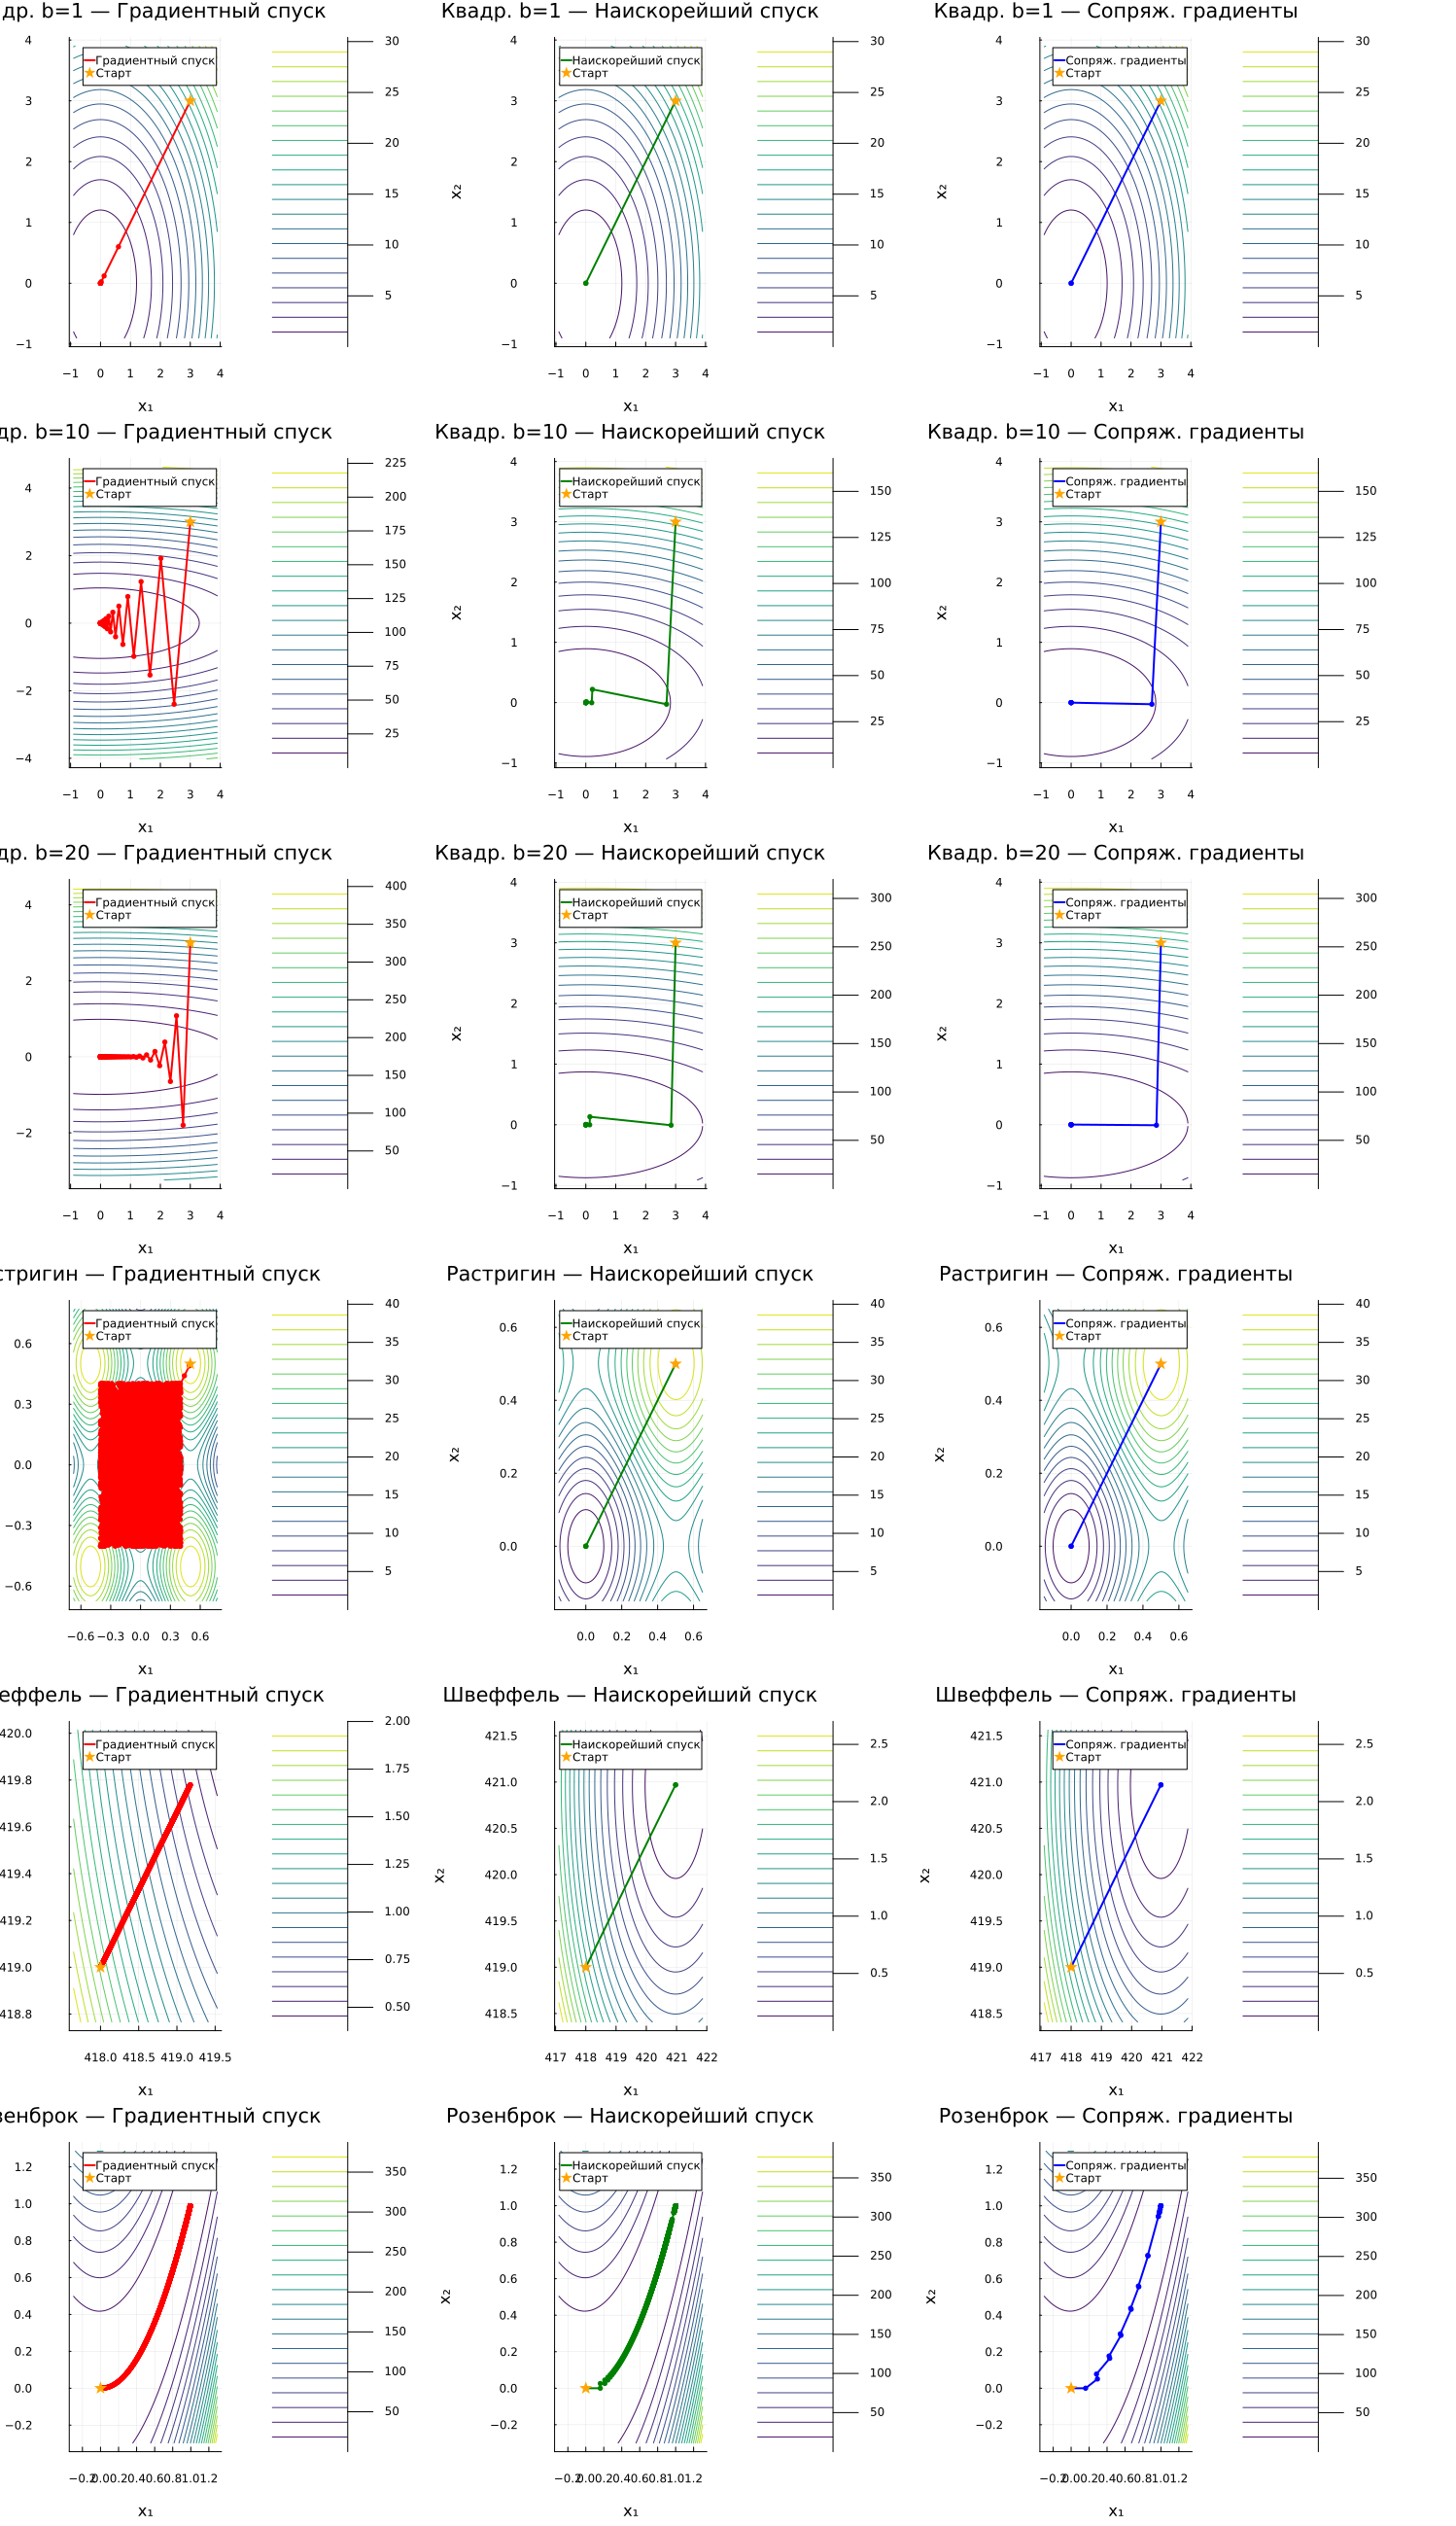

In [1]:
using LinearAlgebra
using Plots
using Printf


f_rast((x, y); A=10.0)           = 2A + (x^2 - A*cos(2π*x)) + (y^2 - A*cos(2π*y))
f_schwef((x, y))                  = 418.9829*2 - (x*sin(sqrt(abs(x))) + y*sin(sqrt(abs(y))))
f_rosen((x, y); a=1.0, b=100.0) = (a - x)^2 + b*(y - x^2)^2


function sven(f, x0; h0=0.01)
    h  = h0
    f0 = f(x0)
    f1 = f(x0 + h)

    if f1 > f0
        h  = -h
        f1 = f(x0 + h)
        if f1 > f0
            return (min(x0 - abs(h), x0 + abs(h)), max(x0 - abs(h), x0 + abs(h)))
        end
    end

    x_prev, x_curr = x0, x0 + h
    f_curr = f1

    for k in 1:100
        h2     = h * 2.0^k
        x_next = x0 + h2
        f_next = f(x_next)

        if f_next >= f_curr
            return (min(x_prev, x_next), max(x_prev, x_next))
        end

        x_prev = x_curr
        x_curr, f_curr = x_next, f_next
    end

    return (min(x_prev, x_curr), max(x_prev, x_curr))
end


function fib_search(f, a, b)
    eps = 1e-5

    if (b - a) <= eps
        return (a + b) / 2
    end

    F = [1, 1]
    while F[end] < (b - a) / eps
        push!(F, F[end] + F[end-1])
    end
    N = length(F)

    x1 = a + (F[N-2] / F[N]) * (b - a)
    x2 = a + (F[N-1] / F[N]) * (b - a)
    f1, f2 = f(x1), f(x2)

    for k in 1:(N - 3)
        if f1 > f2
            a  = x1; x1 = x2; f1 = f2
            x2 = a + (F[N-k-1] / F[N-k]) * (b - a)
            f2 = f(x2)
        else
            b  = x2; x2 = x1; f2 = f1
            x1 = a + (F[N-k-2] / F[N-k]) * (b - a)
            f1 = f(x1)
        end
    end

    return (a + b) / 2
end


function line_search(f, x, d)
    phi(a) = f(x .+ a .* d)
    a, b   = sven(phi, 0.0)
    a      = max(a, 0.0)
    b < a  && ((a, b) = (b, a))
    b      = max(b, a + 1e-8)
    return fib_search(phi, a, b)
end


function numgrad(f, x; h=1e-6)
    xv = collect(Float64, x)
    n  = length(xv)
    g  = zeros(Float64, n)
    ei = zeros(Float64, n)

    for i in 1:n
        fill!(ei, 0.0); ei[i] = 1.0
        g[i] = (f(xv .+ h .* ei) - f(xv .- h .* ei)) / (2h)
    end

    return g
end


function grad_descent(f, x0; alpha=1e-2, eps=1e-6, maxit=2000)
    x  = collect(Float64, x0)
    xs = [copy(x)]

    for _ in 1:maxit
        g    = numgrad(f, x)
        norm(g) < eps && return x, xs
        xnew = x .- alpha .* g
        push!(xs, copy(xnew))
        norm(xnew - x) < eps && return xnew, xs
        x = xnew
    end

    return xs[end], xs
end


function steepest_descent(f, x0; eps=1e-6, maxit=2000)
    x  = collect(Float64, x0)
    xs = [copy(x)]

    for _ in 1:maxit
        g = numgrad(f, x)
        norm(g) < eps && return x, xs

        alpha = line_search(f, x, -g)
        xnew  = x .- alpha .* g
        push!(xs, copy(xnew))
        norm(xnew - x) < eps && return xnew, xs
        x = xnew
    end

    return xs[end], xs
end


function conjugate_gradient(f, x0; eps=1e-6, maxit=2000)
    n  = length(x0)
    x  = collect(Float64, x0)
    xs = [copy(x)]
    g  = numgrad(f, x)
    d  = -copy(g)

    for iter in 1:maxit
        norm(g) < eps && return x, xs

        alpha = line_search(f, x, d)
        xnew  = x .+ alpha .* d
        push!(xs, copy(xnew))
        norm(xnew - x) < eps && return xnew, xs

        gnew  = numgrad(f, xnew)
        denom = dot(g, g)
        beta  = (denom < 1e-30 || iter % n == 0) ? 0.0 : dot(gnew, gnew) / denom

        d    = -gnew .+ beta .* d
        x, g = xnew, gnew
    end

    return xs[end], xs
end


function plot_path(f, hist, title_str, label, color; gridN=200, pad=0.3)
    xs = Float64[p[1] for p in hist]
    ys = Float64[p[2] for p in hist]

    dx = max(maximum(xs) - minimum(xs), 1e-6)
    dy = max(maximum(ys) - minimum(ys), 1e-6)

    xmin = minimum(xs) - pad*dx; xmax = maximum(xs) + pad*dx
    ymin = minimum(ys) - pad*dy; ymax = maximum(ys) + pad*dy

    xg = range(xmin, xmax; length=gridN)
    yg = range(ymin, ymax; length=gridN)
    Z  = [try f((xi, yi)) catch; f(xi, yi) end for yi in yg, xi in xg]

    p = contour(xg, yg, Z;
        xlabel="x₁", ylabel="x₂", title=title_str,
        legend=:topright, color=:viridis, levels=20)

    plot!(p, xs, ys; lw=2, label=label, color=color)

    scatter!(p, xs, ys; ms=3, label="", color=color, markerstrokewidth=0)

    scatter!(p, [xs[1]], [ys[1]];
        ms=7, shape=:star5, color=:orange, label="Старт", markerstrokewidth=0)

    return p
end


f_quad1((x, y)) = 1.0 * x^2 +  1.0 * y^2
f_quad2((x, y)) = 1.0 * x^2 + 10.0 * y^2
f_quad3((x, y)) = 1.0 * x^2 + 20.0 * y^2

x0_q = (3.0, 3.0)
x0_r = (0.5, 0.5)
x0_s = (418.0, 419.0)
x0_ro = (0.0, 0.0)

xm1_q1, h1_q1 = grad_descent(f_quad1, x0_q; alpha=4e-1)
xm2_q1, h2_q1 = steepest_descent(f_quad1, x0_q)
xm3_q1, h3_q1 = conjugate_gradient(f_quad1, x0_q)

xm1_q2, h1_q2 = grad_descent(f_quad2, x0_q; alpha=9e-2)
xm2_q2, h2_q2 = steepest_descent(f_quad2, x0_q)
xm3_q2, h3_q2 = conjugate_gradient(f_quad2, x0_q)

xm1_q3, h1_q3 = grad_descent(f_quad3, x0_q; alpha=4e-2)
xm2_q3, h2_q3 = steepest_descent(f_quad3, x0_q)
xm3_q3, h3_q3 = conjugate_gradient(f_quad3, x0_q)

xm1_rast, h1_rast = grad_descent(f_rast, x0_r; alpha=1e-2)
xm2_rast, h2_rast = steepest_descent(f_rast, x0_r)
xm3_rast, h3_rast = conjugate_gradient(f_rast, x0_r)

xm1_schw, h1_schw = grad_descent(f_schwef, x0_s; alpha=1e-3)
xm2_schw, h2_schw = steepest_descent(f_schwef, x0_s)
xm3_schw, h3_schw = conjugate_gradient(f_schwef, x0_s)

xm1_ros, h1_ros = grad_descent(f_rosen, x0_ro; alpha=2e-3, maxit=5000)
xm2_ros, h2_ros = steepest_descent(f_rosen, x0_ro; maxit=5000)
xm3_ros, h3_ros = conjugate_gradient(f_rosen, x0_ro; maxit=5000)


sep = "─"^102
println(sep)
@printf("  %-18s | %-22s | %-14s | %-22s | %-10s | %-6s | %s\n",
        "Функция", "Метод", "старт x*", "x*", "f(x*)", "iter", "точек")
println(sep)

for (fname, f, x0, xms, hs) in [
    ("Квадр. (b=1)",   f_quad1,  x0_q,  [xm1_q1, xm2_q1, xm3_q1], [h1_q1, h2_q1, h3_q1]),
    ("Квадр. (b=10)",  f_quad2,  x0_q,  [xm1_q2, xm2_q2, xm3_q2], [h1_q2, h2_q2, h3_q2]),
    ("Квадр. (b=20)",  f_quad3,  x0_q,  [xm1_q3, xm2_q3, xm3_q3], [h1_q3, h2_q3, h3_q3]),
    ("Растригин",      f_rast,   x0_r,  [xm1_rast, xm2_rast, xm3_rast], [h1_rast, h2_rast, h3_rast]),
    ("Швеффель",       f_schwef, x0_s,  [xm1_schw, xm2_schw, xm3_schw], [h1_schw, h2_schw, h3_schw]),
    ("Розенброк",      f_rosen,  x0_ro, [xm1_ros,  xm2_ros,  xm3_ros],  [h1_ros,  h2_ros,  h3_ros ]),
]
    for (mname, xm, h) in zip(
        ["Градиентный спуск", "Наискорейший спуск", "Сопряж. градиенты"],
        xms, hs
    )
        fval  = try f((xm[1], xm[2])) catch; f(xm[1], xm[2]) end
        iters = length(h) - 1
        npts  = length(h)
        @printf("  %-18s | %-22s | (%-5.2f, %-5.2f) | (%-9.5f, %-9.5f) | %-10.6f | %-6d | %d\n",
                fname, mname, x0[1], x0[2], xm[1], xm[2], fval, iters, npts)
    end
    println(sep)
end


p11 = plot_path(f_quad1, h1_q1, "Квадр. b=1 — Градиентный спуск",  "Градиентный спуск",  :red)
p12 = plot_path(f_quad1, h2_q1, "Квадр. b=1 — Наискорейший спуск", "Наискорейший спуск", :green)
p13 = plot_path(f_quad1, h3_q1, "Квадр. b=1 — Сопряж. градиенты",  "Сопряж. градиенты",  :blue)

p21 = plot_path(f_quad2, h1_q2, "Квадр. b=10 — Градиентный спуск",  "Градиентный спуск",  :red)
p22 = plot_path(f_quad2, h2_q2, "Квадр. b=10 — Наискорейший спуск", "Наискорейший спуск", :green)
p23 = plot_path(f_quad2, h3_q2, "Квадр. b=10 — Сопряж. градиенты",  "Сопряж. градиенты",  :blue)

p31 = plot_path(f_quad3, h1_q3, "Квадр. b=20 — Градиентный спуск",  "Градиентный спуск",  :red)
p32 = plot_path(f_quad3, h2_q3, "Квадр. b=20 — Наискорейший спуск", "Наискорейший спуск", :green)
p33 = plot_path(f_quad3, h3_q3, "Квадр. b=20 — Сопряж. градиенты",  "Сопряж. градиенты",  :blue)

p41 = plot_path(f_rast,   h1_rast, "Растригин — Градиентный спуск",     "Градиентный спуск",  :red)
p42 = plot_path(f_rast,   h2_rast, "Растригин — Наискорейший спуск",    "Наискорейший спуск", :green)
p43 = plot_path(f_rast,   h3_rast, "Растригин — Сопряж. градиенты",     "Сопряж. градиенты",  :blue)

p51 = plot_path(f_schwef, h1_schw, "Швеффель — Градиентный спуск",      "Градиентный спуск",  :red)
p52 = plot_path(f_schwef, h2_schw, "Швеффель — Наискорейший спуск",     "Наискорейший спуск", :green)
p53 = plot_path(f_schwef, h3_schw, "Швеффель — Сопряж. градиенты",      "Сопряж. градиенты",  :blue)

p61 = plot_path(f_rosen,  h1_ros,  "Розенброк — Градиентный спуск",     "Градиентный спуск",  :red)
p62 = plot_path(f_rosen,  h2_ros,  "Розенброк — Наискорейший спуск",    "Наискорейший спуск", :green)
p63 = plot_path(f_rosen,  h3_ros,  "Розенброк — Сопряж. градиенты",     "Сопряж. градиенты",  :blue)


plot(p11, p12, p13,
     p21, p22, p23,
     p31, p32, p33,
     p41, p42, p43,
     p51, p52, p53,
     p61, p62, p63;
     layout=(6, 3), size=(1500, 2600))